<a href="https://colab.research.google.com/github/theduardomaciel/cc-dl/blob/main/tasks/task-01-simple-perceptron/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [2]:
class Perceptron:
    def __init__(self, seed=0, input_size=2, learning_rate=0.01, epochs=100):
        self.seed = seed
        self.input_size = input_size
        self.learning_rate = learning_rate
        self.epochs = epochs

        ### START CODE HERE ###
        ### TODO: Initialize weights with small Gaussian noise using rng.normal

        # Primeiro, criamos o vetor de pesos com tamanho input_size + 1:
        # 	os primeiros "input_size" pesos são usados para as features (x1, x2, ...)
        # 	e o último peso representa o bias (termo constante).
        # Usamos rng.normal para gerar valores aleatórios pequenos (gaussiana com
        # média 0 e desvio padrão 0.5), o que evita começar com pesos grandes demais
        # e garante que cada execução seja reprodutível por causa da seed local.

        rng = np.random.default_rng(self.seed)
        self.weights = rng.normal(loc=0.0, scale=0.5, size=self.input_size + 1)

        ### END CODE HERE ###

    def activation(self, x):
        ### START CODE HERE ###
        ### TODO: Implement the step activation function

        # Função de ativação "degrau" (step function):
        #   - Se a entrada for >= 0, a saída é +1 (classe positiva);
        #   - Caso contrário, a saída é -1 (classe negativa).
        # O np.where aplica essa regra tanto em um único valor quanto em um
        # array inteiro (todas as amostras de uma vez).

        return np.where(x >= 0, 1, -1)

        ### END CODE HERE ###

    def predict(self, X):
        ### START CODE HERE ###
        ### TODO: Add a bias term to X, compute dot product with weights, and apply activation

        # 1) Adicionamos uma coluna de 1s ao final de X.
        #    Essa coluna representa o termo de bias: o peso extra (última posição
        #    de self.weights) é aprendido junto com os demais durante o treinamento.
        X_bias = np.c_[X, np.ones(X.shape[0])]

        # 2) Calculamos a combinação linear (soma ponderada): z = X · w
        z = np.dot(X_bias, self.weights)

        # 3) Aplicamos a função de ativação degrau para obter a classe prevista (+1 ou -1)
        return self.activation(z)

        ### END CODE HERE ###

    def fit(self, X, y):
        ### START CODE HERE ###
        ### TODO: Implement the perceptron learning rule using weight updates

        # Assim como no predict, adicionamos o bias (coluna de 1s) às amostras.
        X_bias = np.c_[X, np.ones(X.shape[0])]

        # O treinamento é feito em várias épocas (passagens completas pelo dataset).
        for epoch in range(self.epochs):
            # Percorremos cada amostra individualmente (aprendizado online).
            for i in range(X_bias.shape[0]):
                # 1) Calculamos a previsão do modelo para a amostra i.
                z = np.dot(X_bias[i], self.weights)
                prediction = self.activation(z)

                # 2) Se a previsão estiver errada (diferente do rótulo real y[i]),
                #    ajustamos os pesos usando a regra de atualização do perceptron:
                #    w <- w + learning_rate * y * x
                #    - Se y = +1 e previmos -1, somamos x, aproximando a previsão de +1;
                #    - Se y = -1 e previmos +1, subtraímos x, aproximando a previsão de -1.
                if prediction != y[i]:
                    self.weights += self.learning_rate * y[i] * X_bias[i]

        ### END CODE HERE ###

In [3]:
def generate_data(seed=0, samples=200, noise=1.5):
    """
    Generates a synthetic binary classification dataset with two overlapping clusters.

    Parameters:
        seed (int): Random seed used for reproducible dataset generation.
        samples (int): Total number of samples to generate.
        noise (float): Standard deviation of the clusters; higher values increase overlap.

    Returns:
        X (np.ndarray): Feature matrix of shape (samples, 2).
        y (np.ndarray): Label vector of shape (samples,), with values -1 or 1.

    Notes:
        - Uses a locally scoped random number generator to avoid affecting global RNG state.
        - The two clusters are generated using sklearn's make_blobs function.
        - Class labels are mapped from {0, 1} to {-1, 1} to align with the Perceptron formulation.
    """
    rng = np.random.default_rng(seed)  # Local, isolated RNG
    random_state = rng.integers(0, 1_000_000)  # Random seed for make_blobs

    X, y = make_blobs(
        n_samples=samples,
        centers=2,
        cluster_std=noise,
        random_state=random_state,
        return_centers=False,
    )
    y = np.where(y == 0, -1, 1)  # Convert labels to -1 and 1 for perceptron
    return X, y

In [4]:
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary learned by a binary classifier in a 2D feature space.

    Parameters:
        model: Trained classifier with a .predict() method that accepts 2D inputs.
        X (np.ndarray): Input data of shape (n_samples, 2).
        y (np.ndarray): Target labels of shape (n_samples,), expected to be -1 or +1.

    The function creates a dense grid over the input space, uses the model to predict
    labels over the grid, and visualizes the decision boundary along with the data points.
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, levels=[-1, 0, 1], colors=["red", "blue"])

    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k", marker="o")
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ["Class +1", "Class -1"], title="Classes")

    plt.title("Perceptron Decision Boundary")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Test Accuracy: 0.80


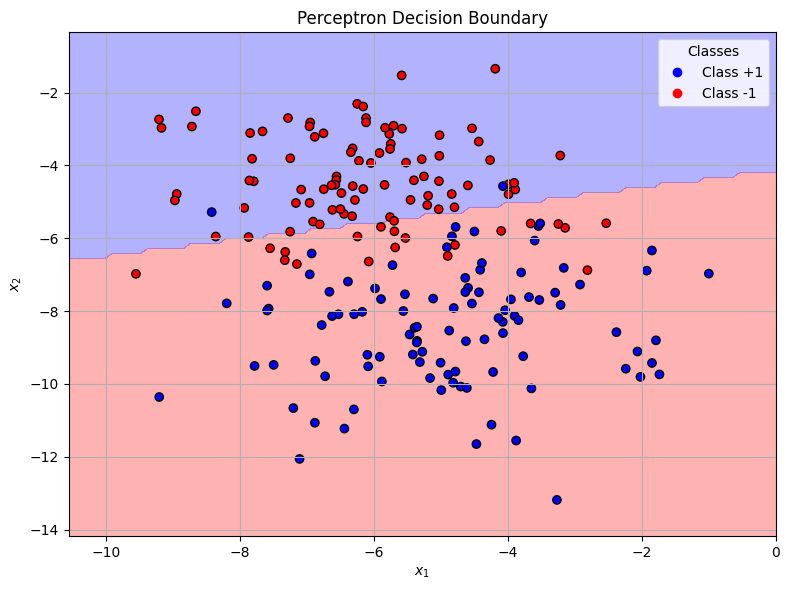

In [5]:
def main():
    X, y = generate_data(39)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = Perceptron(epochs=100)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    accuracy = np.mean(predictions == y_test)
    print(f"Test Accuracy: {accuracy:.2f}")

    plot_decision_boundary(model, X, y)


if __name__ == "__main__":
    main()